<a href="https://colab.research.google.com/github/ClaudioRo81/Data_Scientist/blob/main/Practica3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Práctica 3

**Claudio Rojas Duran**

---
# 1. Preprocesamiento

## Cálculo del valor medio aproximado para datos agrupados en intervalos

Supongamos que los valores de un conjunto determinado de datos se
agrupan en intervalos. Los intervalos y las frecuencias correspondientes
son los siguientes:

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Datos originales: intervalos y frecuencias
data_ej1 = {
    "intervalo": ["1-5", "5-15", "15-20", "20-45", "45-52", "52-80", "80-110"],
    "limite_inferior": [1, 5, 15, 20, 45, 52, 80],
    "limite_superior": [5, 15, 20, 45, 52, 80, 110],
    "frecuencia": [650, 1250, 1600, 850, 620, 530, 380]
}

df1 = pd.DataFrame(data_ej1)
df1

,intervalo,limite_inferior,limite_superior,frecuencia
0,1-5,1,5,650
1,5-15,5,15,1250
2,15-20,15,20,1600
3,20-45,20,45,850
4,45-52,45,52,620
5,52-80,52,80,530
6,80-110,80,110,380


Cuando los datos vienen **agrupados en intervalos** (solo conocemos cuántos datos caen
en cada rango, no su valor exacto), no podemos calcular la media de la forma tradicional
(sumar todos los valores y dividir entre n), porque no tenemos los valores individuales.

**Solución:** se usa la **marca de clase** (punto medio) de cada intervalo como valor
representativo de todos los datos que caen ahí:

$$m_i = \frac{L_i + L_s}{2}$$

Luego, la media aproximada se calcula como un **promedio ponderado**, usando la
frecuencia de cada intervalo como peso:

$$\bar{x} = \frac{\sum_{i=1}^{n} f_i \cdot m_i}{\sum_{i=1}^{n} f_i}$$

### Paso 1: Calcular la marca de cada intervalo

In [4]:
df1["marca_clase"] = (df1["limite_inferior"] + df1["limite_superior"]) / 2
df1

,intervalo,limite_inferior,limite_superior,frecuencia,marca_clase
0,1-5,1,5,650,3.0
1,5-15,5,15,1250,10.0
2,15-20,15,20,1600,17.5
3,20-45,20,45,850,32.5
4,45-52,45,52,620,48.5
5,52-80,52,80,530,66.0
6,80-110,80,110,380,95.0


### Paso 2: Multiplicar cada marca de clase por su frecuencia

In [5]:
df1["frecuencia_x_marca"] = df1["frecuencia"] * df1["marca_clase"]
df1

,intervalo,limite_inferior,limite_superior,frecuencia,marca_clase,frecuencia_x_marca
0,1-5,1,5,650,3.0,1950.0
1,5-15,5,15,1250,10.0,12500.0
2,15-20,15,20,1600,17.5,28000.0
3,20-45,20,45,850,32.5,27625.0
4,45-52,45,52,620,48.5,30070.0
5,52-80,52,80,530,66.0,34980.0
6,80-110,80,110,380,95.0,36100.0


### Paso 3: Calcular el valor medio aproximado

$$\bar{x} = \frac{\sum (f_i \cdot m_i)}{\sum f_i}$$

In [6]:
suma_frecuencias = df1["frecuencia"].sum()
suma_productos = df1["frecuencia_x_marca"].sum()

media_aproximada = suma_productos / suma_frecuencias

print(f"Suma de frecuencias: {suma_frecuencias}")
print(f"Suma de (frecuencia x marca de clase): {suma_productos}")
print(f"Valor medio aproximado: {media_aproximada:.2f}")

Suma de frecuencias: 5880
Suma de (frecuencia x marca de clase): 171225.0
Valor medio aproximado: 29.12


### Conclusión

El valor medio aproximado para este conjunto de datos agrupados es **≈ 29.12**.

Esta aproximación funciona bien cuando los datos dentro de cada intervalo están
distribuidos de manera razonablemente uniforme.

---
# 2. Estadísticas

Consideramos el atributo **Edad**, con los siguientes valores (ya ordenados de forma
creciente):

`12, 15, 16, 16, 19, 19, 19, 19, 20, 21, 22, 22, 25, 25, 25, 30, 30, 33, 33, 34, 35, 35, 35, 36, 36, 36, 36, 42, 43, 45, 47, 52, 71, 76, 77`

In [7]:
edades = [12, 15, 16, 16, 19, 19, 19, 19, 20, 21, 22, 22, 25, 25, 25, 30, 30, 33, 33,
          34, 35, 35, 35, 36, 36, 36, 36, 42, 43, 45, 47, 52, 71, 76, 77]

edades_serie = pd.Series(edades)
n = len(edades_serie)
print(f"Número de datos (n): {n}")
edades_serie

Número de datos (n): 35


,0
0,12
1,15
2,16
3,16
4,19
5,19
6,19
7,19
8,20
9,21


## a) Media y mediana

- **Media**: se suman todos los valores y se divide entre el número de datos (n).
  (a diferencia del ejercicio 1, donde estaban agrupados en intervalos).

$$\bar{x} = \frac{\sum_{i=1}^{n} x_i}{n}$$

- **Mediana**: es el valor que queda justo en medio de los datos ordenados.
  Como n = 35 (impar), la mediana es el dato que ocupa la posición central,
  es decir, la posición $\frac{n+1}{2} = 18$.

In [6]:
media = edades_serie.mean()
mediana = edades_serie.median()

print(f"Media: {media:.2f}")
print(f"Mediana: {mediana}")

Media: 33.06
Mediana: 33.0


**Resultado:** Media ≈ **33.06**, Mediana = **33**.

La media y la mediana son muy parecidas, lo cual sugiere que los datos no están
muy sesgados por valores extremos... aunque en el inciso (e) revisaremos si hay
datos atípicos (como 71, 76, 77) que puedan afectar la interpretación.

## b) Moda

La moda es el valor (o los valores) que más se repiten en el conjunto de datos.
Un conjunto puede tener una sola moda, varias (bimodal, multimodal) o ninguna si
todos los valores tienen la misma frecuencia.

In [8]:
from collections import Counter

conteo = Counter(edades)
frecuencia_maxima = max(conteo.values())
modas = [valor for valor, freq in conteo.items() if freq == frecuencia_maxima]

print("Frecuencia de cada valor:")
for valor, freq in sorted(conteo.items()):
    print(f"  {valor}: {freq}")

print(f"\nFrecuencia máxima: {frecuencia_maxima}")
print(f"Moda(s): {modas}")

Frecuencia de cada valor:
  12: 1
  15: 1
  16: 2
  19: 4
  20: 1
  21: 1
  22: 2
  25: 3
  30: 2
  33: 2
  34: 1
  35: 3
  36: 4
  42: 1
  43: 1
  45: 1
  47: 1
  52: 1
  71: 1
  76: 1
  77: 1

Frecuencia máxima: 4
Moda(s): [19, 36]


**Resultado:** el conjunto es **bimodal**, con modas **19** y **36** (ambas se
repiten 4 veces).

## c) Normalización min-max del valor 38

La normalización min-max transforma un valor $x$ al intervalo $[0, 1]$ usando:

$$x' = \frac{x - \min}{\max - \min}$$

donde $\min$ y $\max$ son el valor mínimo y máximo del conjunto de datos original.

In [10]:
valor_a_normalizar = 38
minimo = edades_serie.min()
maximo = edades_serie.max()

valor_normalizado = (valor_a_normalizar - minimo) / (maximo - minimo)

print(f"Mínimo: {minimo}")
print(f"Máximo: {maximo}")
print(f"Valor normalizado de 38: {valor_normalizado:.2f}")

Mínimo: 12
Máximo: 77
Valor normalizado de 38: 0.40


**Resultado:** el valor 38 normalizado con min-max es **0.40**
(min = 12, max = 77 → (38-12)/(77-12) = 26/65 = 0.40).

## d) Histograma con longitud de intervalo (equi-distancia) = 6

Un histograma de equi-distancia divide el rango de los datos en intervalos (bins)
del mismo ancho. Aquí el ancho pedido es 6.

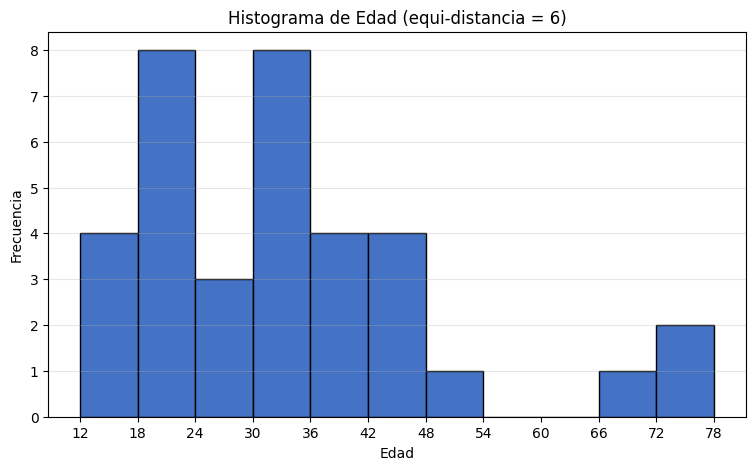

In [9]:
ancho_bin = 6
minimo_h = edades_serie.min()
maximo_h = edades_serie.max()

# Construimos los bordes de los bins para que cubran todo el rango en pasos de 6
bins = np.arange(minimo_h, maximo_h + ancho_bin, ancho_bin)

plt.figure(figsize=(9, 5))
plt.hist(edades_serie, bins=bins, edgecolor="black", color="#4472C4")
plt.title("Histograma de Edad (equi-distancia = 6)")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")
plt.xticks(bins)
plt.grid(axis="y", alpha=0.3)
plt.show()

## e) Detección visual de datos anómalos (outliers)

Para inspeccionar visualmente valores atípicos, usaremos un **boxplot (diagrama de caja)**
: muestra la mediana, los cuartiles, y marca como
puntos individuales cualquier valor que caiga fuera de los "bigotes"
(típicamente 1.5 veces el rango intercuartílico, IQR).

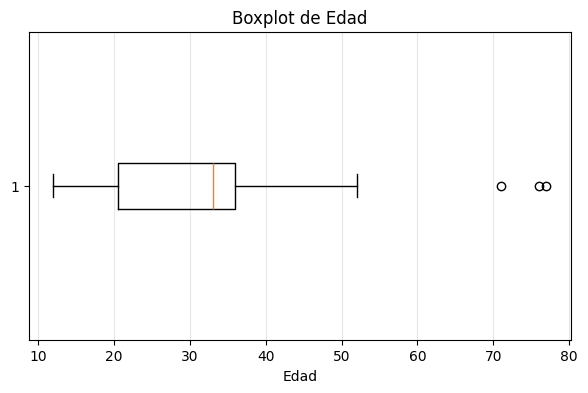

Q1: 20.5, Q3: 36.0, IQR: 15.5
Límites para outliers: [-2.75, 59.25]
Valores atípicos detectados: [71, 76, 77]


In [11]:
plt.figure(figsize=(7, 4))
plt.boxplot(edades_serie, vert=False)
plt.title("Boxplot de Edad")
plt.xlabel("Edad")
plt.grid(axis="x", alpha=0.3)
plt.show()

# Cálculo del rango intercuartílico para identificar outliers de forma explícita
Q1 = edades_serie.quantile(0.25)
Q3 = edades_serie.quantile(0.75)
IQR = Q3 - Q1
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers = edades_serie[(edades_serie < limite_inferior) | (edades_serie > limite_superior)]

print(f"Q1: {Q1}, Q3: {Q3}, IQR: {IQR}")
print(f"Límites para outliers: [{limite_inferior:.2f}, {limite_superior:.2f}]")
print(f"Valores atípicos detectados: {list(outliers)}")

**Resultado:** Tanto en el histograma como en el boxplot se observa que los
valores **71, 76 y 77** están separados del resto de los datos, que se
concentran entre 12 y 52. El cálculo con el criterio de 1.5×IQR confirma que estos
tres valores son **datos anómalos (outliers)**.

---
# 3. Preprocesamiento

Un hospital midió la **Edad** y el **% de Grasa corporal** de 18 adultos elegidos al
azar. A diferencia de los ejercicios anteriores, aquí trabajamos con **dos variables
numéricas** al mismo tiempo, lo que nos permite estudiar no solo cada una por
separado, sino también la **relación entre ellas**.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

edad = [21, 23, 26, 30, 39, 42, 48, 50, 50, 52, 54, 55, 56, 57, 60, 60, 62, 68]
grasa = [9.5, 27, 7.7, 18.8, 32.5, 28.9, 27.5, 27.2, 32.3, 35.5, 42.5, 28.9, 36.6, 31.2, 34.1, 33.0, 42.4, 36.7]

df3 = pd.DataFrame({"edad": edad, "grasa": grasa})
print(f"Número de pacientes: {len(df3)}")
df3

Número de pacientes: 18


,edad,grasa
0,21,9.5
1,23,27.0
2,26,7.7
3,30,18.8
4,39,32.5
5,42,28.9
6,48,27.5
7,50,27.2
8,50,32.3
9,52,35.5


## a) Media, mediana y desviación estándar

- **Media**: promedio aritmético de los valores.
- **Mediana**: valor central de los datos ordenados (con n par, se promedian los
  dos valores centrales).
- **Desviación estándar**: mide qué tan dispersos están los datos respecto a la
  media. Usamos la desviación estándar **muestral** (dividiendo entre n-1), ya que es la adecuada porque los 18 adultos son una
  *muestra* y no la población completa.

In [2]:
resumen = pd.DataFrame({
    "Media": [df3["edad"].mean(), df3["grasa"].mean()],
    "Mediana": [df3["edad"].median(), df3["grasa"].median()],
    "Desviación estándar": [df3["edad"].std(), df3["grasa"].std()]
}, index=["Edad", "% Grasa"])

resumen.round(2)

,Media,Mediana,Desviación estándar
Edad,47.39,51.00,14.16
% Grasa,29.57,31.75,9.50


## b) Diagrama de dispersión

Esto nos permite ver visualmente si existe algún patrón o tendencia entre las
dos variables.

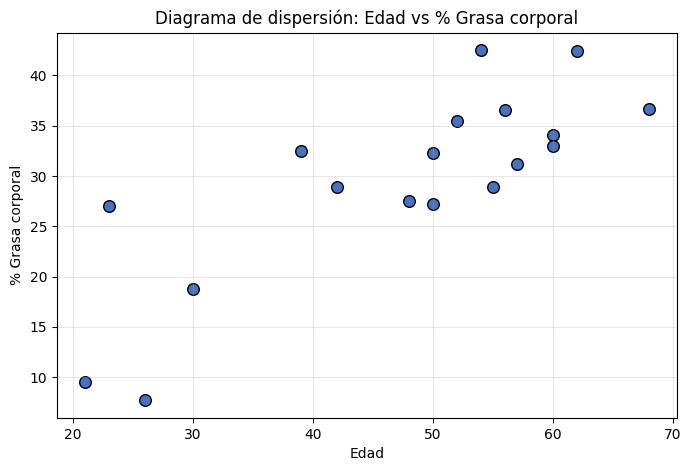

In [3]:
plt.figure(figsize=(8, 5))
plt.scatter(df3["edad"], df3["grasa"], color="#4472C4", edgecolor="black", s=70)
plt.title("Diagrama de dispersión: Edad vs % Grasa corporal")
plt.xlabel("Edad")
plt.ylabel("% Grasa corporal")
plt.grid(alpha=0.3)
plt.show()

**Observación:** Podemos ver que existe una tendencia **creciente**: a mayor edad, tiende a
haber un mayor porcentaje de grasa corporal.

## c) Normalización de Edad y % Grasa

Aplicamos normalización **min-max** a cada variable por separado, para llevar ambas
al intervalo [0, 1]:

$$x' = \frac{x - \min}{\max - \min}$$

Esto es útil para poder comparar variables que originalmente están en escalas
distintas (aquí, años vs porcentaje).

In [4]:
df3["edad_norm"] = (df3["edad"] - df3["edad"].min()) / (df3["edad"].max() - df3["edad"].min())
df3["grasa_norm"] = (df3["grasa"] - df3["grasa"].min()) / (df3["grasa"].max() - df3["grasa"].min())

df3.round(3)

,edad,grasa,edad_norm,grasa_norm
0,21,9.5,0.000,0.052
1,23,27.0,0.043,0.555
2,26,7.7,0.106,0.000
3,30,18.8,0.191,0.319
4,39,32.5,0.383,0.713
5,42,28.9,0.447,0.609
6,48,27.5,0.574,0.569
7,50,27.2,0.617,0.560
8,50,32.3,0.617,0.707
9,52,35.5,0.660,0.799


## d) Detección visual de datos atípicos

Usamos boxplots (uno por variable) para identificar visualmente valores que se
alejen del resto de los datos.

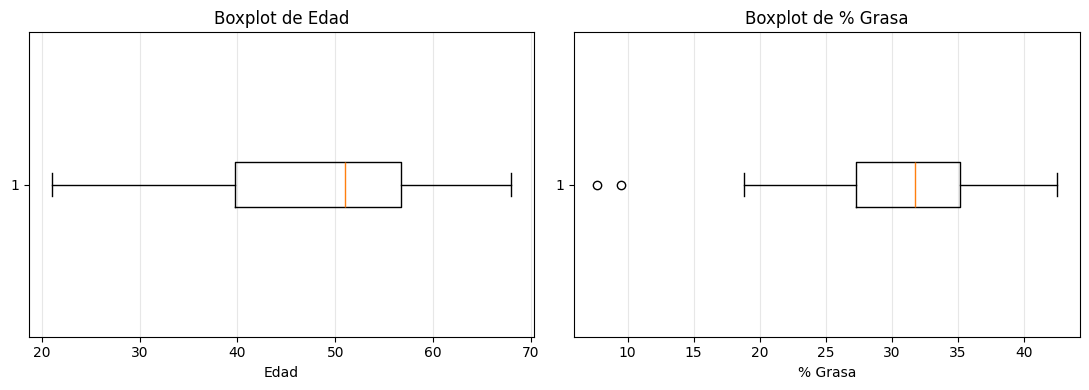

edad: límites [14.25, 82.25] -> outliers: []
grasa: límites [15.46, 46.96] -> outliers: [9.5, 7.7]


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].boxplot(df3["edad"], vert=False)
axes[0].set_title("Boxplot de Edad")
axes[0].set_xlabel("Edad")
axes[0].grid(axis="x", alpha=0.3)

axes[1].boxplot(df3["grasa"], vert=False)
axes[1].set_title("Boxplot de % Grasa")
axes[1].set_xlabel("% Grasa")
axes[1].grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

# Verificación numérica con el criterio 1.5 x IQR, para cada variable
for col in ["edad", "grasa"]:
    Q1 = df3[col].quantile(0.25)
    Q3 = df3[col].quantile(0.75)
    IQR = Q3 - Q1
    lim_inf = Q1 - 1.5 * IQR
    lim_sup = Q3 + 1.5 * IQR
    outliers = df3[(df3[col] < lim_inf) | (df3[col] > lim_sup)][col]
    print(f"{col}: límites [{lim_inf:.2f}, {lim_sup:.2f}] -> outliers: {list(outliers)}")

**Resultado:** En edad no se observan puntos fuera de los bigotes, sin embargo para la variable % Grasa podemos identificar los valores atipicos/outliers 9.5 y 7.7

## e) Coeficiente de correlación de Pearson

El coeficiente de correlación de Pearson ($r$) mide la fuerza y dirección de la
relación **lineal** entre dos variables numéricas:

$$r = \frac{\sum (x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum (x_i - \bar{x})^2 \sum (y_i - \bar{y})^2}}$$

- $r$ cercano a **+1**: relación lineal positiva fuerte (cuando una sube, la otra
  también).
- $r$ cercano a **-1**: relación lineal negativa fuerte (cuando una sube, la otra
  baja).
- $r$ cercano a **0**: poca o ninguna relación lineal.

In [6]:
correlacion = df3["edad"].corr(df3["grasa"])
print(f"Coeficiente de correlación de Pearson (Edad vs % Grasa): {correlacion:.4f}")

Coeficiente de correlación de Pearson (Edad vs % Grasa): 0.8069


Existe una correlación lineal **positiva y fuerte** entre la
edad y el porcentaje de grasa corporal: conforme aumenta la edad de los pacientes,
tiende a aumentar también su porcentaje de grasa corporal.

---
# 4. Distancias

## Cálculo de distancias entre atributos numéricos

Dadas dos tuplas (puntos) con atributos numéricos, existen varias formas de medir
qué tan "lejos" están una de otra. Sean:

$$X_1 = (7, 3) \qquad X_2 = (10, 12)$$

Cada una de las tres distancias que se piden usa las diferencias entre coordenadas
correspondientes, $d_1 = |7-10| = 3$ y $d_2 = |3-12| = 9$, pero las combina de forma
distinta:

- **Distancia máxima :** toma solo la mayor de las diferencias absolutas.
  $$D_{max}(X_1, X_2) = \max_i |x_{1i} - x_{2i}|$$

- **Distancia de Manhattan :** suma las diferencias absolutas
  (como moverse en una cuadrícula de calles, solo en horizontal y vertical).
  $$D_{Man}(X_1, X_2) = \sum_i |x_{1i} - x_{2i}|$$

- **Distancia Euclidiana:** es la distancia "en línea recta", la que conocemos de
  geometría (teorema de Pitágoras).
  $$D_{Euc}(X_1, X_2) = \sqrt{\sum_i (x_{1i} - x_{2i})^2}$$

In [7]:
import numpy as np
import matplotlib.pyplot as plt

X1 = np.array([7, 3])
X2 = np.array([10, 12])

diferencias = np.abs(X1 - X2)
print(f"X1 = {tuple(X1)}, X2 = {tuple(X2)}")
print(f"Diferencias absolutas por atributo: {tuple(diferencias)}")

X1 = (np.int64(7), np.int64(3)), X2 = (np.int64(10), np.int64(12))
Diferencias absolutas por atributo: (np.int64(3), np.int64(9))


## a) Distancia máxima

In [8]:
d_max = diferencias.max()
print(f"Distancia máxima: {d_max}")

Distancia máxima: 9


**Resultado:** $D_{max} = \max(3, 9) = 9$

## b) Distancia de Manhattan

In [11]:
d_manhattan = diferencias.sum()
print(f"Distancia de Manhattan: {d_manhattan}")

Distancia de Manhattan: 12


**Resultado:** $D_{Man} = 3 + 9 = 12$

## c) Distancia Euclidiana

In [9]:
d_euclidiana = np.sqrt((diferencias ** 2).sum())
print(f"Distancia Euclidiana: {d_euclidiana:.4f}")

Distancia Euclidiana: 9.4868


**Resultado:** $D_{Euc} = \sqrt{3^2 + 9^2} = \sqrt{90} \approx 9.49$

## Comparación de resultados

| Distancia | Valor |
|---|---|
| Máxima (Chebyshev) | 9 |
| Manhattan | 12 |
| Euclidiana | ≈ 9.49 |

Notamos que $D_{max} \leq D_{Euc} \leq D_{Man}$, lo cual siempre se cumple: la
distancia máxima es una cota inferior y la de Manhattan una cota superior de la
distancia euclidiana.

## Representación gráfica de las tres distancias

Sobre el plano, con $X_1$ y $X_2$ como puntos:

- La **Euclidiana** es la línea recta que une directamente $X_1$ con $X_2$.
- La **Manhattan** es el camino en "escalera" (solo movimientos horizontales y
  verticales) que va de $X_1$ a $X_2$.
- La **máxima (Chebyshev)** se ilustra con el lado más largo del cuadrado/rectángulo
  formado por las diferencias en cada eje (aquí, el tramo vertical de longitud 9).

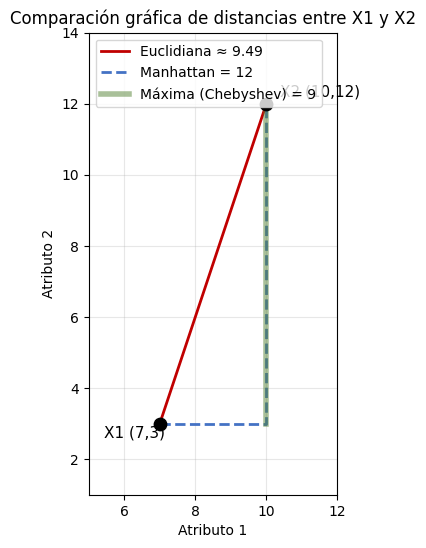

In [12]:
fig, ax = plt.subplots(figsize=(7, 6))

# Puntos
ax.scatter(*X1, color="black", zorder=5, s=80)
ax.scatter(*X2, color="black", zorder=5, s=80)
ax.annotate("X1 (7,3)", X1, textcoords="offset points", xytext=(-40, -10), fontsize=11)
ax.annotate("X2 (10,12)", X2, textcoords="offset points", xytext=(10, 5), fontsize=11)

# Distancia Euclidiana: línea recta directa
ax.plot([X1[0], X2[0]], [X1[1], X2[1]], color="#C00000", linewidth=2,
        label=f"Euclidiana ≈ {d_euclidiana:.2f}")

# Distancia de Manhattan: camino en escalera (horizontal + vertical)
ax.plot([X1[0], X2[0], X2[0]], [X1[1], X1[1], X2[1]], color="#4472C4",
        linewidth=2, linestyle="--", label=f"Manhattan = {d_manhattan}")

# Distancia máxima: el tramo más largo (aquí, el vertical, longitud 9)
ax.plot([X2[0], X2[0]], [X1[1], X2[1]], color="#548235", linewidth=4,
        alpha=0.5, label=f"Máxima (Chebyshev) = {d_max}")

ax.set_xlim(5, 12)
ax.set_ylim(1, 14)
ax.set_xlabel("Atributo 1")
ax.set_ylabel("Atributo 2")
ax.set_title("Comparación gráfica de distancias entre X1 y X2")
ax.legend(loc="upper left")
ax.grid(alpha=0.3)
ax.set_aspect("equal")
plt.show()

**Interpretación de la gráfica:** la línea roja (Euclidiana) es el camino más
corto en línea recta. La línea azul punteada (Manhattan) recorre primero un eje y
luego el otro, por lo que su longitud total (12) es mayor. La línea verde gruesa
(Chebyshev) corresponde solo al mayor de los dos desplazamientos por eje (el
vertical, de 9 unidades), y por eso es la más corta de las tres.

---
# 5. Distancias

## Cálculo de distancias con atributos categóricos

A diferencia del ejercicio 4, aquí las tuplas mezclan **atributos categóricos**
(Color_ojos, Sexo) con un **atributo numérico** (Edad). Las fórmulas de distancia
(Euclidiana, Manhattan, Mahalanobis) están definidas para vectores numéricos, así
que el primer paso es **convertir los atributos categóricos en variables
numéricas**.

Cada categoría de un atributo
se convierte en una columna binaria (0/1). Por ejemplo, `Color_ojos` (con
categorías Azul, Café, Negro, Verde) se convierte en 4 columnas binarias, y
`Sexo` (F, M) en 2 columnas binarias. La `Edad` se deja como está. Así, cada tupla
queda representada como un solo vector numérico, y podemos aplicarle las fórmulas
de distancia normales.

Se agrega el registro **ID 8** con mis datos: Color_ojos = Café, Sexo = M,
Edad = 23. **El ID no se usa como atributo para calcular distancias** (es solo un
identificador).

In [13]:
import pandas as pd
import numpy as np

data = {
    "ID": [1, 2, 3, 4, 5, 6, 7, 8],
    "Color_ojos": ["Verde", "Negro", "Azul", "Negro", "Café", "Verde", "Café", "Café"],
    "Sexo": ["M", "F", "M", "F", "M", "M", "F", "M"],
    "Edad": [21, 24, 30, 28, 23, 29, 24, 23]
}

df5 = pd.DataFrame(data)
df5

,ID,Color_ojos,Sexo,Edad
0,1,Verde,M,21
1,2,Negro,F,24
2,3,Azul,M,30
3,4,Negro,F,28
4,5,Café,M,23
5,6,Verde,M,29
6,7,Café,F,24
7,8,Café,M,23


### Codificación de los atributos categóricos

In [15]:
# encoding de Color_ojos y Sexo (el ID se deja fuera del cálculo de distancias)
dummies = pd.get_dummies(df5[["Color_ojos", "Sexo"]], columns=["Color_ojos", "Sexo"]).astype(float)

# Vector de atributos por tupla
X5 = pd.concat([dummies, df5["Edad"].astype(float)], axis=1)
X5.index = df5["ID"]
X5

,Color_ojos_Azul,Color_ojos_Café,Color_ojos_Negro,Color_ojos_Verde,Sexo_F,Sexo_M,Edad
ID,,,,,,,
1,0.0,0.0,0.0,1.0,0.0,1.0,21.0
2,0.0,0.0,1.0,0.0,1.0,0.0,24.0
3,1.0,0.0,0.0,0.0,0.0,1.0,30.0
4,0.0,0.0,1.0,0.0,1.0,0.0,28.0
5,0.0,1.0,0.0,0.0,0.0,1.0,23.0
6,0.0,0.0,0.0,1.0,0.0,1.0,29.0
7,0.0,1.0,0.0,0.0,1.0,0.0,24.0
8,0.0,1.0,0.0,0.0,0.0,1.0,23.0


## b) Distancia Euclidiana entre las tuplas 3 y 6

- Tupla 3: Azul, M, 30
- Tupla 6: Verde, M, 29

$$D_{Euc}(X_i, X_j) = \sqrt{\sum_k (x_{ik} - x_{jk})^2}$$

In [16]:
v3 = X5.loc[3].values
v6 = X5.loc[6].values

dist_euc_3_6 = np.linalg.norm(v3 - v6)

print(f"Vector tupla 3: {v3}")
print(f"Vector tupla 6: {v6}")
print(f"Distancia Euclidiana (3, 6): {dist_euc_3_6:.4f}")

Vector tupla 3: [ 1.  0.  0.  0.  0.  1. 30.]
Vector tupla 6: [ 0.  0.  0.  1.  0.  1. 29.]
Distancia Euclidiana (3, 6): 1.7321


**Resultado:** $D_{Euc}(3,6) = \sqrt{2} \approx 1.41$

Las tuplas difieren en el color de ojos (Azul vs Verdes) y en 1 año de edad; el sexo es igual (M en ambas).

## c) Distancia Euclidiana entre las tuplas 5 y 8

- Tupla 5: Café, M, 23
- Tupla 8 (mis datos): Café, M, 23

In [17]:
v5 = X5.loc[5].values
v8 = X5.loc[8].values

dist_euc_5_8 = np.linalg.norm(v5 - v8)

print(f"Vector tupla 5: {v5}")
print(f"Vector tupla 8: {v8}")
print(f"Distancia Euclidiana (5, 8): {dist_euc_5_8:.4f}")

Vector tupla 5: [ 0.  1.  0.  0.  0.  1. 23.]
Vector tupla 8: [ 0.  1.  0.  0.  0.  1. 23.]
Distancia Euclidiana (5, 8): 0.0000


**Resultado:** $D_{Euc}(5,8) = 0$

Tiene sentido: las tuplas 5 y 8 son **idénticas** en los tres atributos
(Color_ojos = Café, Sexo = M, Edad = 23), por lo que la distancia entre ellas es
cero.

## d) Lo mismo con distancia de Manhattan y distancia de Mahalanobis

**Manhattan:**
$$D_{Man}(X_i, X_j) = \sum_k |x_{ik} - x_{jk}|$$

**Mahalanobis:** a diferencia de la Euclidiana, toma en cuenta la **correlación y
la dispersión** entre los atributos, usando la matriz de covarianza $S$ del
conjunto de datos:

$$D_{Mah}(X_i, X_j) = \sqrt{(X_i - X_j) \, S^{-1} \, (X_i - X_j)^{T}}$$



In [18]:
# --- Manhattan ---
dist_man_3_6 = np.sum(np.abs(v3 - v6))
dist_man_5_8 = np.sum(np.abs(v5 - v8))

print(f"Distancia de Manhattan (3, 6): {dist_man_3_6:.4f}")
print(f"Distancia de Manhattan (5, 8): {dist_man_5_8:.4f}")

# --- Mahalanobis ---
matriz_cov = np.cov(X5.values.T)
cov_inv = np.linalg.pinv(matriz_cov)  # pseudo-inversa (la matriz es singular por el one-hot)

def distancia_mahalanobis(u, v, cov_inv):
    diff = u - v
    return np.sqrt(diff @ cov_inv @ diff.T)

dist_mah_3_6 = distancia_mahalanobis(v3, v6, cov_inv)
dist_mah_5_8 = distancia_mahalanobis(v5, v8, cov_inv)

print(f"\nDistancia de Mahalanobis (3, 6): {dist_mah_3_6:.4f}")
print(f"Distancia de Mahalanobis (5, 8): {dist_mah_5_8:.4f}")

Distancia de Manhattan (3, 6): 3.0000
Distancia de Manhattan (5, 8): 0.0000

Distancia de Mahalanobis (3, 6): 3.6469
Distancia de Mahalanobis (5, 8): 0.0000


**Resumen de resultados:**

| Distancia | Tuplas 3 y 6 | Tuplas 5 y 8 |
|---|---|---|
| Euclidiana | 1.41 | 0.00 |
| Manhattan | 3.00 | 0.00 |
| Mahalanobis | 3.65 | 0.00 |

Como era de esperarse, **todas las distancias entre 5 y 8 son cero**, porque son
tuplas idénticas. Entre 3 y 6, la Mahalanobis da un valor mayor que la Euclidiana
porque, al considerar la covarianza entre atributos, penaliza más las diferencias
en direcciones donde los datos varían menos.

## e) Normaliza la Edad

Aplicamos normalización min-max a la columna `Edad`, usando el mínimo y máximo de
las 8 tuplas (incluyendo la tupla 8):

$$Edad' = \frac{Edad - \min(Edad)}{\max(Edad) - \min(Edad)}$$

In [21]:
df5["Edad_normalizada"] = (df5["Edad"] - df5["Edad"].min()) / (df5["Edad"].max() - df5["Edad"].min())
df5[["ID", "Color_ojos", "Sexo", "Edad", "Edad_normalizada"]].round(2)

,ID,Color_ojos,Sexo,Edad,Edad_normalizada
0,1,Verde,M,21,0.00
1,2,Negro,F,24,0.33
2,3,Azul,M,30,1.00
3,4,Negro,F,28,0.78
4,5,Café,M,23,0.22
5,6,Verde,M,29,0.89
6,7,Café,F,24,0.33
7,8,Café,M,23,0.22


---
# 6. Definición de Modelos

Con los datos del ejercicio 5 (las 8 tuplas con `Color_ojos`, `Sexo` y `Edad`,
incluyendo mi registro ID 8).

Como `Color_ojos` y `Sexo` son categóricos, reutilizamos la misma **codificación
one-hot** del ejercicio anterior para poder calcular correlaciones y ajustar un
modelo de regresión (que solo trabajan con valores numéricos).

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

data = {
    "ID": [1, 2, 3, 4, 5, 6, 7, 8],
    "Color_ojos": ["Verde", "Negro", "Azul", "Negro", "Café", "Verde", "Café", "Café"],
    "Sexo": ["M", "F", "M", "F", "M", "M", "F", "M"],
    "Edad": [21, 24, 30, 28, 23, 29, 24, 23]
}

df6 = pd.DataFrame(data)

# One-hot encoding (igual que en el ejercicio 5)
dummies = pd.get_dummies(df6[["Color_ojos", "Sexo"]], columns=["Color_ojos", "Sexo"]).astype(float)
X6 = pd.concat([dummies, df6["Edad"].astype(float)], axis=1)
X6.index = df6["ID"]
X6

,Color_ojos_Azul,Color_ojos_Café,Color_ojos_Negro,Color_ojos_Verde,Sexo_F,Sexo_M,Edad
ID,,,,,,,
1,0.0,0.0,0.0,1.0,0.0,1.0,21.0
2,0.0,0.0,1.0,0.0,1.0,0.0,24.0
3,1.0,0.0,0.0,0.0,0.0,1.0,30.0
4,0.0,0.0,1.0,0.0,1.0,0.0,28.0
5,0.0,1.0,0.0,0.0,0.0,1.0,23.0
6,0.0,0.0,0.0,1.0,0.0,1.0,29.0
7,0.0,1.0,0.0,0.0,1.0,0.0,24.0
8,0.0,1.0,0.0,0.0,0.0,1.0,23.0


## a) Matriz de correlación

La matriz de correlación muestra, para cada par de variables, el coeficiente de
correlación de Pearson (entre -1 y 1). Aquí la calculamos sobre las variables
codificadas (columnas one-hot de Color_ojos y Sexo, más Edad).

In [23]:
matriz_correlacion = X6.corr()
matriz_correlacion.round(2)

,Color_ojos_Azul,Color_ojos_Café,Color_ojos_Negro,Color_ojos_Verde,Sexo_F,Sexo_M,Edad
Color_ojos_Azul,1.00,-0.29,-0.22,-0.22,-0.29,0.29,0.58
Color_ojos_Café,-0.29,1.00,-0.45,-0.45,-0.07,0.07,-0.48
Color_ojos_Negro,-0.22,-0.45,1.00,-0.33,0.75,-0.75,0.14
Color_ojos_Verde,-0.22,-0.45,-0.33,1.00,-0.45,0.45,-0.05
Sexo_F,-0.29,-0.07,0.75,-0.45,1.00,-1.00,0.02
Sexo_M,0.29,0.07,-0.75,0.45,-1.00,1.00,-0.02
Edad,0.58,-0.48,0.14,-0.05,0.02,-0.02,1.00


### Visualización de la matriz de correlación

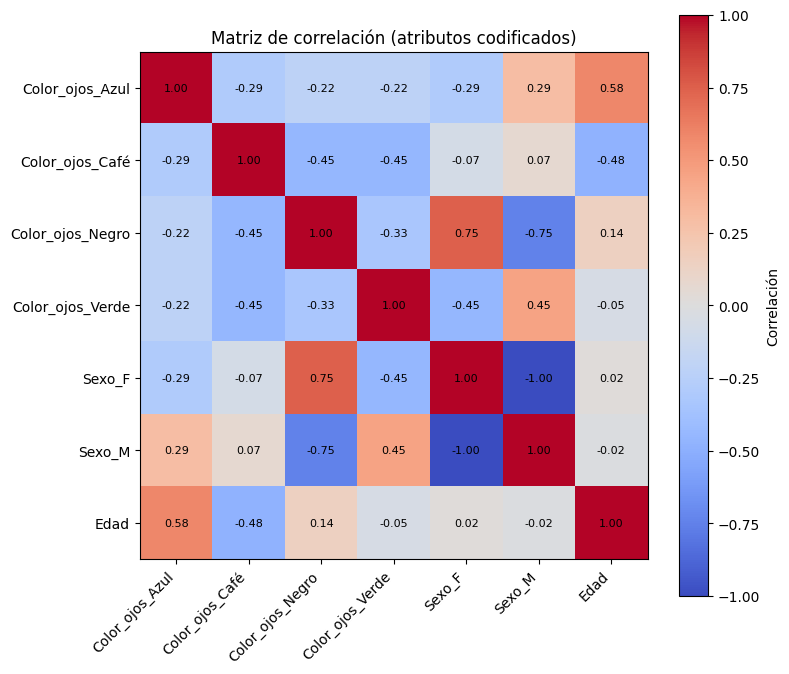

In [24]:
fig, ax = plt.subplots(figsize=(8, 7))
cax = ax.imshow(matriz_correlacion, cmap="coolwarm", vmin=-1, vmax=1)

ax.set_xticks(range(len(matriz_correlacion.columns)))
ax.set_yticks(range(len(matriz_correlacion.columns)))
ax.set_xticklabels(matriz_correlacion.columns, rotation=45, ha="right")
ax.set_yticklabels(matriz_correlacion.columns)

for i in range(len(matriz_correlacion.columns)):
    for j in range(len(matriz_correlacion.columns)):
        ax.text(j, i, f"{matriz_correlacion.iloc[i, j]:.2f}", ha="center", va="center",
                color="black", fontsize=8)

fig.colorbar(cax, label="Correlación")
ax.set_title("Matriz de correlación (atributos codificados)")
plt.tight_layout()
plt.show()

**Conclusión del inciso a):**

- La correlación más fuerte con `Edad` es con `Color_ojos_Azul` (**0.58**): la
  única persona con ojos azules (ID 3) es también la de mayor edad (30), lo que
  infla esta correlación.
- `Color_ojos_Café` tiene correlación negativa con `Edad` (**-0.48**): las personas
  con ojos café en esta muestra tienden a ser más jóvenes (23-24 años).
- `Sexo_F` y `Sexo_M` son perfectamente correlacionadas de forma negativa entre sí
  (**-1.00**), lo cual es esperado: son columnas complementarias (si una es 1, la
  otra es 0).
- En general, las correlaciones entre `Edad` y `Sexo` son muy débiles (≈ 0.02),
  es decir, en esta muestra el sexo casi no se relaciona con la edad.
- Estos resultados hay que interpretarlos con cuidado: solo tenemos **8 tuplas**,
  por lo que cualquier correlación es muy sensible a un par de observaciones.

## b) Modelo de regresión lineal

Ajustamos un modelo de **regresión lineal múltiple** para predecir la `Edad` a
partir de `Color_ojos` y `Sexo`. Como los predictores son categóricos, usamos
codificación one-hot **dejando fuera una categoría de referencia por atributo**
(`drop_first=True`), para evitar la
"trampa de las variables ficticias"
(*dummy variable trap*): si incluyéramos las 4 columnas de color y quedaran
correlacionadas perfectamente (siempre suman 1), el modelo no podría estimar
coeficientes únicos.

- Categoría de referencia para color: **Azul**
- Categoría de referencia para sexo: **F**

El modelo tiene la forma:

$$Edad = \beta_0 + \beta_1 \cdot Café + \beta_2 \cdot Negro + \beta_3 \cdot Verde + \beta_4 \cdot Sexo_M$$

In [25]:
dummies_reg = pd.get_dummies(df6[["Color_ojos", "Sexo"]], columns=["Color_ojos", "Sexo"],
                              drop_first=True).astype(float)

X = dummies_reg.values
y = df6["Edad"].values

modelo = LinearRegression()
modelo.fit(X, y)

predicciones = modelo.predict(X)
r2 = r2_score(y, predicciones)

print("Coeficientes:")
for nombre, coef in zip(dummies_reg.columns, modelo.coef_):
    print(f"  {nombre}: {coef:.2f}")
print(f"Intercepto (β0): {modelo.intercept_:.2f}")
print(f"R² del modelo: {r2:.4f}")

Coeficientes:
  Color_ojos_Café: -7.00
  Color_ojos_Negro: -5.00
  Color_ojos_Verde: -5.00
  Sexo_M: -1.00
Intercepto (β0): 31.00
R² del modelo: 0.4702


**Expresión del modelo obtenido:**

$$Edad = 31.00 - 7.00 \cdot Café - 5.00 \cdot Negro - 5.00 \cdot Verde - 1.00 \cdot Sexo_M$$

(donde cada variable vale 1 si la tupla pertenece a esa categoría, y 0 si no; la
categoría de referencia, Azul y Sexo F, no aparece explícitamente: su efecto ya
está incluido en el intercepto).

In [27]:
comparacion = pd.DataFrame({
    "ID": df6["ID"],
    "Edad_real": y,
    "Edad_predicha": predicciones.round(2)
})
comparacion

,ID,Edad_real,Edad_predicha
0,1,21,25.0
1,2,24,26.0
2,3,30,30.0
3,4,28,26.0
4,5,23,23.0
5,6,29,25.0
6,7,24,24.0
7,8,23,23.0


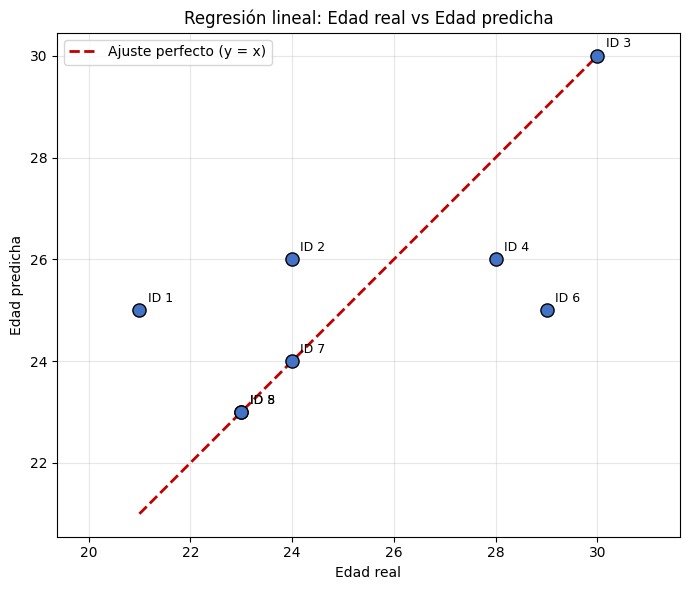

In [28]:
plt.figure(figsize=(7, 6))

plt.scatter(comparacion["Edad_real"], comparacion["Edad_predicha"],
            color="#4472C4", edgecolor="black", s=90, zorder=3)

# Línea de referencia y = x (ajuste perfecto)
min_val = min(comparacion["Edad_real"].min(), comparacion["Edad_predicha"].min())
max_val = max(comparacion["Edad_real"].max(), comparacion["Edad_predicha"].max())
plt.plot([min_val, max_val], [min_val, max_val], color="#C00000",
         linestyle="--", linewidth=2, label="Ajuste perfecto (y = x)")

# Etiquetar cada punto con su ID
for _, fila in comparacion.iterrows():
    plt.annotate(f'ID {int(fila["ID"])}', (fila["Edad_real"], fila["Edad_predicha"]),
                 textcoords="offset points", xytext=(6, 6), fontsize=9)

plt.title("Regresión lineal: Edad real vs Edad predicha")
plt.xlabel("Edad real")
plt.ylabel("Edad predicha")
plt.legend()
plt.grid(alpha=0.3)
plt.axis("equal")
plt.tight_layout()
plt.show()

**Conclusión del inciso b):**

- El intercepto (31.00) representa la edad estimada para la categoría de
  referencia: una persona con ojos **Azules** y Sexo **F** (aunque no exista
  ninguna combinación así en los datos, es el punto de partida del
  modelo).
- Todos los coeficientes son negativos, lo que indica que, respecto a tener ojos
  azules, tener ojos café, negro o verde se asocia con una edad menor (7, 5 y 5
  años menos, respectivamente) esto fue impulsado por que la única tupla con
  ojos azules (ID 3) es la persona de mayor edad del grupo.
- Ser hombre (`Sexo_M = 1`) se asocia con 1 año menos en promedio, un efecto muy
  pequeño comparado con el del color de ojos.
- El modelo logra un $R^2 \approx 0.47$: explica cerca de la mitad de la
  variabilidad de la edad, lo cual es un ajuste bajo lo cual es razonable considerando
  que solo tenemos **8 observaciones y 4 variables predictoras** muy pocos datos.